<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/5_1_Multiomics_Integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimental Session 1 — Multi-Omics Data Integration

**Course:** Integrative Genomics and Computational Approaches  
**Platform:** Google Colab  
**Level:** MSc / advanced undergraduate / research training

### Aim
Integrate simulated genomics, transcriptomics, and clinical features; perform quality checks, normalization, correlation analysis, dimensionality reduction, and identify molecular signatures associated with a phenotype.

### Learning outcomes
By the end of this experiment, students should be able to:
1. Represent multiple omics layers as matched samples.
2. Normalize heterogeneous molecular measurements.
3. Integrate omics matrices using concatenation and PCA.
4. Quantify cross-omics correlations.
5. Identify candidate multi-omics biomarkers.

> **Reproducibility note:** This notebook uses a fully reproducible synthetic dataset so it runs reliably in Colab. The workflow can later be replaced with TCGA/GEO data.

In [1]:
# Install/import packages
!pip -q install pandas numpy scipy scikit-learn seaborn matplotlib openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

np.random.seed(42)
print("Environment ready")

Environment ready


## 1. Generate a reproducible multi-omics dataset

We create:
- RNA expression features
- DNA methylation features
- protein abundance features
- clinical phenotype

The same 120 samples are used across layers, which is essential for sample-level integration.

In [2]:
n = 120
samples = [f"S{i:03d}" for i in range(1, n+1)]

# Latent disease signal shared across omics
latent = np.random.normal(size=n)
phenotype = (latent + np.random.normal(0, 0.9, n) > 0.25).astype(int)

rna = pd.DataFrame(
    np.random.normal(size=(n, 20)) + latent[:, None] * np.random.normal(0.6, 0.15, (1,20)),
    index=samples, columns=[f"RNA_G{i:02d}" for i in range(1,21)]
)

meth = pd.DataFrame(
    np.random.normal(size=(n, 15)) - latent[:, None] * np.random.normal(0.5, 0.12, (1,15)),
    index=samples, columns=[f"METH_CpG{i:02d}" for i in range(1,16)]
)

prot = pd.DataFrame(
    np.random.normal(size=(n, 10)) + latent[:, None] * np.random.normal(0.7, 0.15, (1,10)),
    index=samples, columns=[f"PROT_P{i:02d}" for i in range(1,11)]
)

clinical = pd.DataFrame({
    "Age": np.random.normal(58, 10, n),
    "Stage": np.random.choice([1,2,3,4], n, p=[.20,.30,.35,.15]),
    "Phenotype": phenotype
}, index=samples)

display(rna.head())
display(meth.head())
display(prot.head())
display(clinical.head())

,RNA_G01,RNA_G02,RNA_G03,RNA_G04,RNA_G05,RNA_G06,RNA_G07,RNA_G08,RNA_G09,RNA_G10,RNA_G11,RNA_G12,RNA_G13,RNA_G14,RNA_G15,RNA_G16,RNA_G17,RNA_G18,RNA_G19,RNA_G20
S001,-0.359686,0.167046,0.739861,1.115198,-0.983453,-0.094943,-0.204522,-0.460025,2.064646,0.770236,-1.030490,1.329088,2.458242,1.407279,-1.270355,-0.122537,1.483583,-0.343311,0.754651,1.113884
S002,-1.047413,-0.137962,-3.306646,-1.093822,-0.312928,-1.314466,1.557137,-1.483949,-0.523327,0.029069,1.377141,-1.550330,1.069612,-0.094099,-1.050824,0.361422,0.138747,-0.701639,-0.016720,-0.479746
S003,0.677911,1.029560,1.892280,-0.912555,2.415785,-1.639717,0.200832,0.840375,0.671122,-0.146427,0.092299,0.043216,-0.151127,1.338340,0.681718,-0.221277,1.182128,0.782403,1.218170,1.071992
S004,0.498167,0.303823,1.467466,1.375216,0.643985,0.851863,2.106839,0.001138,1.464483,0.917755,0.488756,2.359682,1.855927,1.962768,2.069011,1.130042,1.346314,0.806932,1.277242,0.910068
S005,-0.107044,0.462323,-0.928941,1.974799,-1.108238,-1.327117,1.030632,0.700538,0.483079,0.456163,-0.120856,-1.091108,-0.082628,-0.853851,0.857733,-0.317563,-0.927637,-0.493146,0.266404,-0.723648


,METH_CpG01,METH_CpG02,METH_CpG03,METH_CpG04,METH_CpG05,METH_CpG06,METH_CpG07,METH_CpG08,METH_CpG09,METH_CpG10,METH_CpG11,METH_CpG12,METH_CpG13,METH_CpG14,METH_CpG15
S001,-1.494799,-1.253659,0.298617,-1.266017,0.249421,-1.546566,0.549148,-1.505777,0.297539,0.354184,-0.964393,0.257147,-0.065103,-0.819638,-1.307326
S002,-1.873773,0.449466,-1.481682,0.183770,-0.203940,0.729088,-0.218809,-0.253386,0.802786,0.410617,0.390650,0.559700,-1.444954,0.834950,0.695634
S003,-1.432908,-0.711662,-0.428680,-0.548720,0.055096,1.197402,0.691852,-1.668527,0.289875,0.974982,0.037845,0.667355,1.587776,0.657567,-0.140274
S004,0.066341,-0.954623,-0.891701,-1.325454,0.907904,-1.368593,0.615489,-0.337988,-2.180458,-0.464663,-2.920608,-0.370642,-0.112960,-1.453335,-0.792549
S005,2.104632,-0.336706,-0.918141,1.631414,2.063366,0.088279,1.152426,1.470289,-0.622389,-0.357345,1.357032,1.838164,0.716345,-0.747446,2.127904


,PROT_P01,PROT_P02,PROT_P03,PROT_P04,PROT_P05,PROT_P06,PROT_P07,PROT_P08,PROT_P09,PROT_P10
S001,0.863261,-0.100087,1.204488,-1.019992,1.364440,-0.917693,0.608035,-0.572477,0.904652,0.271738
S002,-1.691958,0.320189,-0.702604,0.776901,-0.085118,0.318363,-1.047265,-0.665234,-0.556416,0.771619
S003,2.132712,-0.334339,1.660916,-1.681346,-0.789251,-0.597807,-0.932336,-1.228033,0.871027,0.184501
S004,1.450120,1.797629,1.639043,1.806068,0.882673,-0.338175,2.045844,0.246972,0.141451,0.759310
S005,-1.077424,-0.587647,0.132901,0.171799,-1.044224,-0.618204,0.922431,0.367859,1.909478,1.036037


,Age,Stage,Phenotype
S001,43.059622,2,1
S002,70.551458,2,0
S003,53.023275,2,1
S004,45.318632,3,1
S005,56.317409,1,1


## 2. Quality control and normalization

For integration, features measured on different scales should be standardized. We also inspect missing values and feature variability.

In [3]:
def qc_report(df, name):
    print(f"{name}: shape={df.shape}, missing={df.isna().sum().sum()}")
    print("Median feature SD:", np.median(df.std()))

for df, name in [(rna,"RNA"), (meth,"Methylation"), (prot,"Protein")]:
    qc_report(df, name)

scaler = StandardScaler()
rna_z = pd.DataFrame(scaler.fit_transform(rna), index=samples, columns=rna.columns)
meth_z = pd.DataFrame(scaler.fit_transform(meth), index=samples, columns=meth.columns)
prot_z = pd.DataFrame(scaler.fit_transform(prot), index=samples, columns=prot.columns)

integrated = pd.concat([rna_z, meth_z, prot_z], axis=1)
print("Integrated matrix:", integrated.shape)

RNA: shape=(120, 20), missing=0
Median feature SD: 1.1251854406766741
Methylation: shape=(120, 15), missing=0
Median feature SD: 1.1625165515939642
Protein: shape=(120, 10), missing=0
Median feature SD: 1.179931725058589
Integrated matrix: (120, 45)


## 3. PCA of individual and integrated omics layers

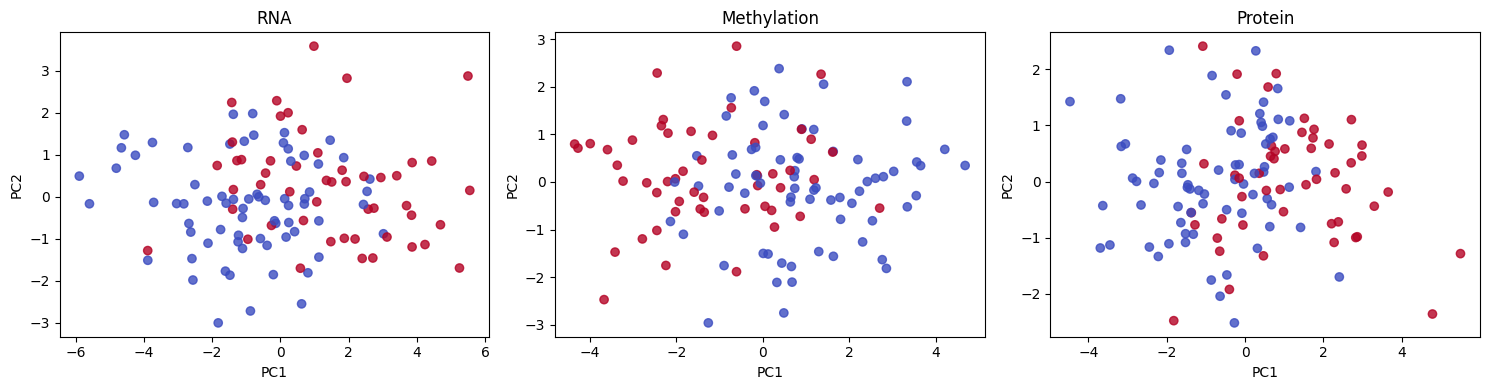

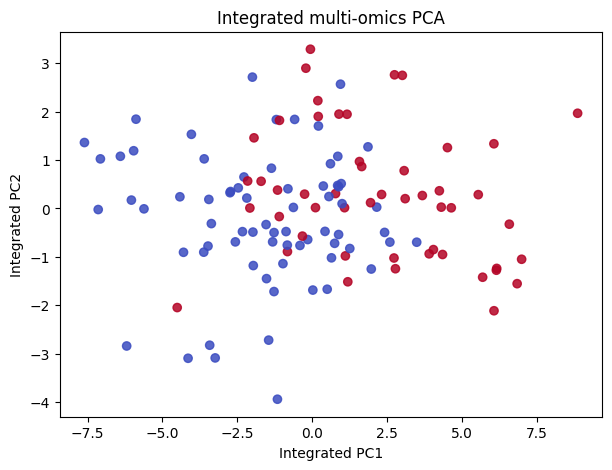

Explained variance: [0.24815435 0.04065482]


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, df, title in zip(axes, [rna_z, meth_z, prot_z], ["RNA", "Methylation", "Protein"]):
    pca = PCA(n_components=2)
    X = pca.fit_transform(df)
    ax.scatter(X[:,0], X[:,1], c=phenotype, cmap="coolwarm", alpha=.8)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

pca_all = PCA(n_components=2)
X_all = pca_all.fit_transform(integrated)
plt.figure(figsize=(7,5))
plt.scatter(X_all[:,0], X_all[:,1], c=phenotype, cmap="coolwarm", alpha=.85)
plt.xlabel("Integrated PC1")
plt.ylabel("Integrated PC2")
plt.title("Integrated multi-omics PCA")
plt.show()

print("Explained variance:", pca_all.explained_variance_ratio_)

## 4. Cross-omics correlation analysis

A practical multi-omics question is whether molecular measurements from different layers move together.

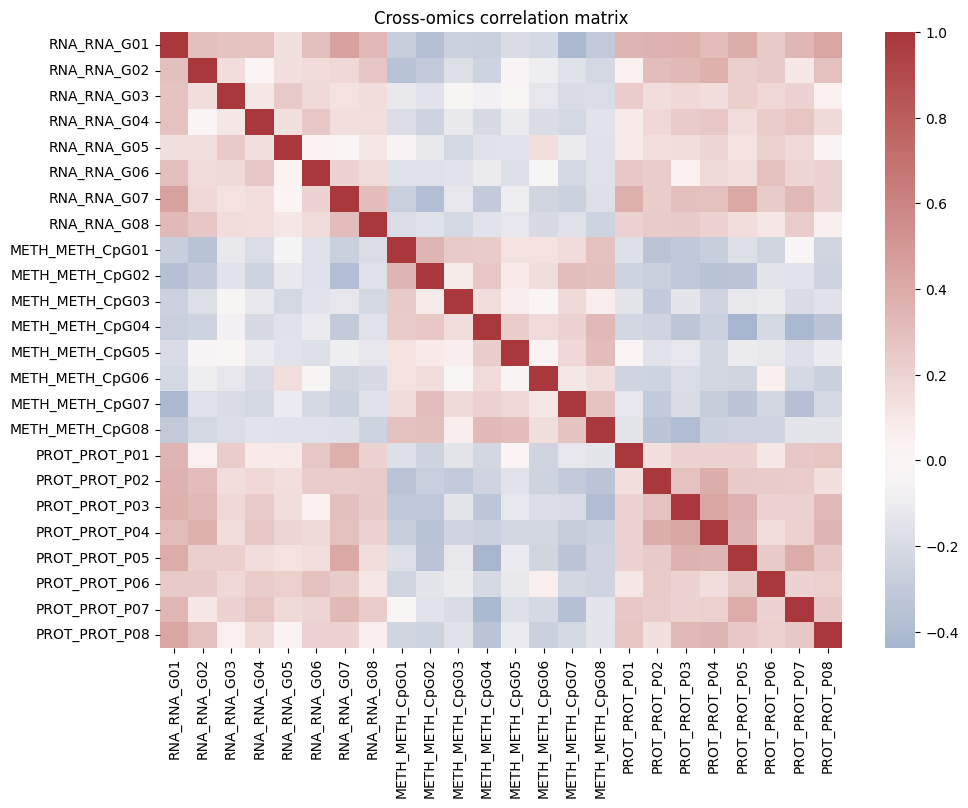

,Feature_A,Feature_B,Correlation
0,METH_METH_CpG04,PROT_PROT_P05,-0.438030
1,RNA_RNA_G01,PROT_PROT_P08,0.436148
2,RNA_RNA_G07,PROT_PROT_P05,0.420971
3,RNA_RNA_G01,METH_METH_CpG07,-0.420364
4,METH_METH_CpG04,PROT_PROT_P07,-0.416777
5,RNA_RNA_G01,PROT_PROT_P05,0.393620
6,METH_METH_CpG08,PROT_PROT_P03,-0.389692
7,RNA_RNA_G07,METH_METH_CpG02,-0.385462
8,RNA_RNA_G07,PROT_PROT_P01,0.378212
9,RNA_RNA_G02,PROT_PROT_P04,0.372997


In [5]:
cross = pd.concat([
    rna_z.iloc[:, :8].add_prefix("RNA_"),
    meth_z.iloc[:, :8].add_prefix("METH_"),
    prot_z.iloc[:, :8].add_prefix("PROT_")
], axis=1)

corr = cross.corr()
plt.figure(figsize=(11,8))
sns.heatmap(corr, cmap="vlag", center=0)
plt.title("Cross-omics correlation matrix")
plt.show()

# Strongest absolute cross-layer correlations
pairs = []
cols = cross.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        a,b = cols[i], cols[j]
        if a[:4] != b[:4]:
            pairs.append((a,b,corr.loc[a,b]))
pairs = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
pd.DataFrame(pairs[:15], columns=["Feature_A","Feature_B","Correlation"])

## 5. Simple multi-omics predictive model

We combine all omics features and train a logistic regression model. This is a baseline—not a claim of clinical performance.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    integrated, phenotype, test_size=.25, stratify=phenotype, random_state=42
)

model = LogisticRegression(max_iter=3000, penalty="l2")
model.fit(X_train, y_train)
pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred))
print("Test ROC-AUC:", round(roc_auc_score(y_test, prob), 3))

coef = pd.Series(model.coef_[0], index=integrated.columns).sort_values(key=np.abs, ascending=False)
display(coef.head(15).to_frame("Coefficient"))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80        18
           1       0.69      0.75      0.72        12

    accuracy                           0.77        30
   macro avg       0.76      0.76      0.76        30
weighted avg       0.77      0.77      0.77        30

Test ROC-AUC: 0.755


,Coefficient
METH_CpG10,-1.014733
RNA_G19,-0.849661
RNA_G05,0.841176
RNA_G01,-0.813475
RNA_G07,0.791010
PROT_P07,0.721968
METH_CpG11,-0.692171
METH_CpG03,-0.631117
RNA_G02,0.629888
RNA_G14,-0.627334


## 6. Export integrated data

The exported CSV can be reused in later sessions.

In [7]:
integrated_export = integrated.copy()
integrated_export["Phenotype"] = phenotype
integrated_export.to_csv("multiomics_integrated_dataset.csv")

print("Saved: multiomics_integrated_dataset.csv")

Saved: multiomics_integrated_dataset.csv


## Student exercises

1. Repeat PCA using only the 10 most variable features from each omics layer.
2. Compare a model using RNA alone with the integrated model.
3. Calculate Spearman rather than Pearson correlations.
4. Identify the top 10 features associated with phenotype using univariate statistics.
5. Explain why batch effects can create false multi-omics associations.
6. Design a replacement strategy using TCGA RNA-seq + DNA methylation + clinical data.

### Expected outputs
- QC summary
- Individual-omics PCA
- Integrated PCA
- Cross-omics correlation heatmap
- Baseline predictive model
- Exported integrated dataset